# FEATURE ENGINEERING

## Load and imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned data from Notebook 2
# We go back to cleaned data NOT preprocessed
# because feature engineering needs original values
# like account IDs and timestamps

df = pd.read_csv(r"C:\Users\tjain\Downloads\HI-Small_Trans.csv")

print("Dataset loaded!")
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded!
Shape  : (5078336, 32)
Columns: ['Hour', 'Day', 'DayOfWeek', 'IsWeekend', 'Sender Bank ID', 'Receiver Bank ID', 'is_cross_bank', 'Sender_Account_Encoded', 'Receiver_Account_Encoded', 'is_self_transfer', 'Amount Paid', 'Amount Received', 'amount_vs_account_median', 'is_currency_mismatch', 'is_amount_outlier_iqr', 'is_amount_outlier_zscore', 'is_account_level_outlier', 'is_high_velocity', 'outlier_score', 'is_outlier', 'txn_count_per_sender_hour', 'txn_count_per_sender_day', 'fmt_ACH', 'fmt_Bitcoin', 'fmt_Cash', 'fmt_Cheque', 'fmt_Credit Card', 'fmt_Reinvestment', 'fmt_Wire', 'Payment_Currency_Encoded', 'Receiving_Currency_Encoded', 'Is Laundering']


In [2]:
df.groupby(['Sender_Account_Encoded', 'Day'])['Sender_Account_Encoded'].transform('count')

0          1
1          1
2          1
3          4
4          6
          ..
5078331    1
5078332    1
5078333    1
5078334    1
5078335    1
Name: Sender_Account_Encoded, Length: 5078336, dtype: int64

In [3]:
import numpy as np

df['Amount_Paid_Log'] = np.log1p(df['Amount Paid'])   # Replace with your actual amount column

## Velocity features (how fast money is moving)

In [4]:
# ============================================================
# VELOCITY FEATURES
# ============================================================
# Velocity = How frequently an account transacts within
# a specific time window.
#
# High transaction frequency is a strong AML indicator.
# ============================================================

# ── 1. Transactions made by sender on that day ──────────────
df['sender_txn_count_per_day'] = (
    df.groupby(['Sender_Account_Encoded', 'Day'])
      ['Amount_Paid_Log']
      .transform('count')
)

# ── 2. Transactions made by sender during that hour of that day ──
df['sender_txn_count_per_hour'] = (
    df.groupby(['Sender_Account_Encoded', 'Day', 'Hour'])
      ['Amount_Paid_Log']
      .transform('count')
)

# ── 3. Total amount sent by sender on that day ──────────────
df['sender_total_amount_per_day'] = (
    df.groupby(['Sender_Account_Encoded', 'Day'])
      ['Amount_Paid_Log']
      .transform('sum')
)

# ── 4. Number of unique receivers contacted by sender per day ──
df['sender_unique_receivers_per_day'] = (
    df.groupby(['Sender_Account_Encoded', 'Day'])
      ['Receiver_Account_Encoded']
      .transform('nunique')
)

# ============================================================
# Display average values for Normal vs Fraud
# ============================================================

print("✅ Velocity features created!")

velocity_cols = [
    'sender_txn_count_per_day',
    'sender_txn_count_per_hour',
    'sender_total_amount_per_day',
    'sender_unique_receivers_per_day'
]

print("\nAverage velocity features:")
print(
    df.groupby('Is Laundering')[velocity_cols]
      .mean()
      .round(2)
)

✅ Velocity features created!

Average velocity features:
               sender_txn_count_per_day  sender_txn_count_per_hour  \
Is Laundering                                                        
0                                952.59                      42.97   
1                               1363.65                      61.36   

               sender_total_amount_per_day  sender_unique_receivers_per_day  
Is Laundering                                                                
0                                  6951.21                           464.86  
1                                  9954.33                           665.72  


## Amount ratio features (is this unusual for this account)

In [5]:
# AMOUNT RATIO = how does this transaction compare
# to THIS SPECIFIC ACCOUNT's own history?
#
# This is personalised detection
# ₹5,00,000 is normal for a business but
# suspicious for a student account
#
# We compare each transaction to the sender's
# own mean, median, and standard deviation

# ── Sender's historical statistics ──────────────────────
sender_mean   = df.groupby('Sender_Account_Encoded')['Amount_Paid_Log'].transform('mean')
sender_median = df.groupby('Sender_Account_Encoded')['Amount_Paid_Log'].transform('median')
sender_std    = df.groupby('Sender_Account_Encoded')['Amount_Paid_Log'].transform('std').fillna(1)
sender_max    = df.groupby('Sender_Account_Encoded')['Amount_Paid_Log'].transform('max')

# ── Amount ratio vs sender's own mean ───────────────────
# ratio > 1 means this transaction is above average
# ratio > 5 means very suspicious
df['amount_ratio_vs_sender_mean'] = (
    df['Amount_Paid_Log'] / (sender_mean + 0.001)
)

# ── Amount ratio vs sender's own median ─────────────────
# Median is more robust than mean for skewed data
df['amount_ratio_vs_sender_median'] = (
    df['Amount_Paid_Log'] / (sender_median + 0.001)
)

# ── Z-score at account level ─────────────────────────────
# How many standard deviations from this account's mean?
df['sender_amount_zscore'] = (
    (df['Amount_Paid_Log'] - sender_mean) / (sender_std + 0.001)
)

# ── Is this the largest transaction this account ever sent?
df['is_sender_max_transaction'] = (
    df['Amount_Paid_Log'] == sender_max
).astype(int)

print("Amount ratio features created!")
print("\nAverage ratios for fraud vs normal:")
ratio_cols = [
    'amount_ratio_vs_sender_mean',
    'amount_ratio_vs_sender_median',
    'sender_amount_zscore'
]
print(df.groupby('Is Laundering')[ratio_cols].mean().round(3))

Amount ratio features created!

Average ratios for fraud vs normal:
               amount_ratio_vs_sender_mean  amount_ratio_vs_sender_median  \
Is Laundering                                                               
0                                    0.999                          1.183   
1                                    1.098                          1.150   

               sender_amount_zscore  
Is Laundering                        
0                            -0.000  
1                             0.253  


## Structuring features (breaking large amounts into small ones)

In [6]:
# STRUCTURING = deliberately breaking a large amount
# into many smaller transactions to avoid detection
#
# Example:
# Instead of sending ₹10,00,000 once (gets flagged)
# Send ₹99,000 × 11 times (each looks normal)
#
# Banks must report transactions above ₹10,00,000
# Launderers stay JUST below this threshold
# This is called "smurfing"

# ── Round number flag ────────────────────────────────────
# Launderers use round numbers to split amounts evenly
# ₹5,00,000 exactly is more suspicious than ₹4,97,832

# Get original amount before log transform
# We need raw amount for structuring detection
df_orig = pd.read_csv('cleaned_transactions.csv')
df['Amount_Paid_Raw'] = df_orig['Amount Paid'] \
    if 'Amount Paid' in df_orig.columns \
    else np.expm1(df['Amount_Paid_Log'])

df['is_round_amount'] = (
    df['Amount_Paid_Raw'] % 10000 == 0
).astype(int)

# ── Just below reporting threshold ──────────────────────
# In IBM dataset threshold is around 1,000,000
# Launderers send 990,000 - 999,999 to avoid it
df['is_just_below_threshold'] = (
    (df['Amount_Paid_Raw'] >= 900000) &
    (df['Amount_Paid_Raw'] <  1000000)
).astype(int)

# ── Structuring score ────────────────────────────────────
# High velocity + small amounts = structuring
# Many small transactions from same sender same day

sender_day_count  = df['sender_txn_count_per_day']
sender_day_amount = df['sender_total_amount_per_day']

# Average transaction size when sender sends multiple txns
df['avg_txn_size_today'] = (
    sender_day_amount / (sender_day_count + 0.001)
)

# Flag if: many transactions AND each is small
df['is_structuring_pattern'] = (
    (sender_day_count > 5) &                    # more than 5 today
    (df['Amount_Paid_Raw'] < 100000)             # each below 1 lakh
).astype(int)

print("Structuring features created!")
print("\nStructuring pattern — fraud vs normal:")
struct_cols = [
    'is_round_amount',
    'is_just_below_threshold',
    'is_structuring_pattern'
]
print(df.groupby('Is Laundering')[struct_cols].mean().round(4))

Structuring features created!

Structuring pattern — fraud vs normal:
               is_round_amount  is_just_below_threshold  \
Is Laundering                                             
0                          0.0                   0.0023   
1                          0.0                   0.0031   

               is_structuring_pattern  
Is Laundering                          
0                              0.4006  
1                              0.2712  


## Network/relationship features

In [7]:
# NETWORK FEATURES = who is connected to who
#
# Money laundering always involves a NETWORK
# of accounts working together
# These features capture that network behaviour
#
# Think of it as:
# A suspicious account is one that is
# connected to many other suspicious accounts

# ── How many unique banks did this sender use ────────────
df['sender_unique_banks'] = df.groupby(
    'Sender_Account_Encoded'
)['Sender Bank ID'].transform('nunique')

# ── How many unique senders does this receiver get from ──
# One receiver getting from 100 different senders = mule
df['receiver_unique_senders'] = df.groupby(
    'Receiver_Account_Encoded'
)['Sender_Account_Encoded'].transform('nunique')

# ── Sender bank to receiver bank fraud rate ──────────────
# Some bank pairs appear more in fraud transactions
bank_pair_fraud = df.groupby(
    ['Sender Bank ID', 'Receiver Bank ID']
)['Is Laundering'].transform('mean')

df['bank_pair_fraud_rate'] = bank_pair_fraud

# ── Has this receiver received from this sender before ───
# First time transfer = higher risk
sender_receiver_count = df.groupby(
    ['Sender_Account_Encoded', 'Receiver_Account_Encoded']
)['Amount_Paid_Log'].transform('count')

df['is_first_time_transfer'] = (
    sender_receiver_count == 1
).astype(int)

# ── Receiver concentration ───────────────────────────────
# Is sender sending ALL money to ONE receiver?
# Or spreading across many?
# Concentrating to one receiver = suspicious

total_sent = df.groupby(
    'Sender_Account_Encoded'
)['Amount_Paid_Log'].transform('sum')

amount_to_this_receiver = df.groupby(
    ['Sender_Account_Encoded', 'Receiver_Account_Encoded']
)['Amount_Paid_Log'].transform('sum')

df['receiver_concentration'] = (
    amount_to_this_receiver / (total_sent + 0.001)
)

print("Network features created!")
print("\nNetwork features — fraud vs normal:")
net_cols = [
    'sender_unique_banks',
    'receiver_unique_senders',
    'is_first_time_transfer',
    'receiver_concentration'
]
print(df.groupby('Is Laundering')[net_cols].mean().round(4))

Network features created!

Network features — fraud vs normal:
               sender_unique_banks  receiver_unique_senders  \
Is Laundering                                                 
0                              1.0                   3.8321   
1                              1.0                   6.5443   

               is_first_time_transfer  receiver_concentration  
Is Laundering                                                  
0                              0.0888                  0.4533  
1                              0.7292                  0.2218  


## Time pattern features

In [8]:
# TIME PATTERNS reveal suspicious behaviour
# that amount-based features miss
#
# Fraudsters often:
# 1. Transact at unusual hours (night)
# 2. Send money in rapid bursts
# 3. Transact on weekends when monitoring is less

# ── Is this a night transaction ──────────────────────────
# Night = between 10pm and 5am
df['is_night_transaction'] = (
    (df['Hour'] >= 22) | (df['Hour'] <= 4)
).astype(int)

# ── Is this an early morning transaction ─────────────────
# 12am - 6am is most suspicious window
df['is_early_morning'] = (
    (df['Hour'] >= 0) & (df['Hour'] <= 6)
).astype(int)

# ── Transaction gap feature ──────────────────────────────
# How different is this hour from sender's usual hour?
sender_usual_hour = df.groupby(
    'Sender_Account_Encoded'
)['Hour'].transform('median')

df['hour_deviation_from_usual'] = abs(
    df['Hour'] - sender_usual_hour
)

# ── Weekend high amount flag ─────────────────────────────
# Large amount on weekend = very suspicious
df['is_weekend_large_amount'] = (
    (df['IsWeekend'] == 1) &
    (df['amount_ratio_vs_sender_mean'] > 3)
).astype(int)

# ── Night high amount flag ───────────────────────────────
df['is_night_large_amount'] = (
    (df['is_night_transaction'] == 1) &
    (df['amount_ratio_vs_sender_mean'] > 3)
).astype(int)

print("Time pattern features created!")
print("\nTime features — fraud vs normal:")
time_cols = [
    'is_night_transaction',
    'is_early_morning',
    'hour_deviation_from_usual',
    'is_weekend_large_amount',
    'is_night_large_amount'
]
print(df.groupby('Is Laundering')[time_cols].mean().round(4))

Time pattern features created!

Time features — fraud vs normal:
               is_night_transaction  is_early_morning  \
Is Laundering                                           
0                            0.3533            0.3539   
1                            0.2069            0.2295   

               hour_deviation_from_usual  is_weekend_large_amount  \
Is Laundering                                                       
0                                 5.3659                   0.0001   
1                                 4.3961                   0.0006   

               is_night_large_amount  
Is Laundering                         
0                             0.0009  
1                             0.0004  


## Currency and payment features

In [9]:
# CURRENCY FEATURES catch the layering stage
# of money laundering where criminals convert
# money between currencies to hide its origin
#
# Sending in Bitcoin receiving in USD = suspicious
# Converting through 3 currencies = very suspicious

# ── Currency mismatch already created in cleaning ───────
# But let's create more specific flags

# ── Is crypto involved ───────────────────────────────────
# Bitcoin transactions have higher fraud rate
df['is_crypto_payment'] = (
    df['Payment_Currency_Encoded'] ==
    df['Payment_Currency_Encoded'].max()  # Bitcoin usually highest encoded
).astype(int)

# ── Same currency flag ───────────────────────────────────
df['is_same_currency'] = (
    df['Payment_Currency_Encoded'] ==
    df['Receiving_Currency_Encoded']
).astype(int)

# ── High risk payment format flags ───────────────────────
# From EDA we know certain formats have higher fraud rate
# Cash and Reinvestment are highest risk

if 'fmt_Cash' in df.columns:
    df['is_high_risk_format'] = (
        (df['fmt_Cash'] == 1) |
        (df['fmt_Reinvestment'] == 1)
    ).astype(int)
else:
    df['is_high_risk_format'] = 0

print("Currency and payment features created!")
print("\nCurrency features — fraud vs normal:")
curr_cols = [
    'is_same_currency',
    'is_high_risk_format'
]
print(df.groupby('Is Laundering')[curr_cols].mean().round(4))

Currency and payment features created!

Currency features — fraud vs normal:
               is_same_currency  is_high_risk_format
Is Laundering                                       
0                        0.9858               0.1916
1                        1.0000               0.0209


## Complete risk score features

In [10]:
# COMPOSITE RISK SCORE = combine multiple signals
# into one powerful master feature
#
# This gives the model a head start by telling it
# "this transaction has 7 suspicious signals"
# before it even starts learning
#
# Each flag adds 1 point to risk score
# Maximum possible score = 12

df['composite_risk_score'] = (
    # Amount signals
    df['is_amount_outlier_iqr'].fillna(0)        +
    df['is_amount_outlier_zscore'].fillna(0)     +
    df['is_account_level_outlier'].fillna(0)     +

    # Velocity signals
    df['is_high_velocity'].fillna(0)             +
    (df['sender_txn_count_per_day'] > 10).astype(int) +

    # Structuring signals
    df['is_round_amount'].fillna(0)              +
    df['is_structuring_pattern'].fillna(0)       +

    # Network signals
    df['is_self_transfer'].fillna(0)             +
    df['is_first_time_transfer'].fillna(0)       +
    df['is_cross_bank'].fillna(0)                +

    # Time signals
    df['is_night_transaction'].fillna(0)         +
    df['is_currency_mismatch'].fillna(0)
)

print("Composite risk score created!")
print("\nRisk score distribution:")
print(df['composite_risk_score'].value_counts().sort_index())

print("\nFraud rate by composite risk score:")
fraud_by_risk = df.groupby(
    'composite_risk_score'
)['Is Laundering'].mean() * 100

for score, rate in fraud_by_risk.items():
    bar = '█' * int(rate * 3)
    print(f"  Score {score:2}: {rate:.4f}%  {bar}")

Composite risk score created!

Risk score distribution:
composite_risk_score
0      17457
1    1222039
2    1562700
3    1117717
4     743665
5     328193
6      76079
7      10127
8        358
9          1
Name: count, dtype: int64

Fraud rate by composite risk score:
  Score  0: 0.0516%  
  Score  1: 0.0284%  
  Score  2: 0.1231%  
  Score  3: 0.1138%  
  Score  4: 0.1392%  
  Score  5: 0.1426%  
  Score  6: 0.1406%  
  Score  7: 0.1382%  
  Score  8: 0.2793%  
  Score  9: 0.0000%  


## Visualize new features

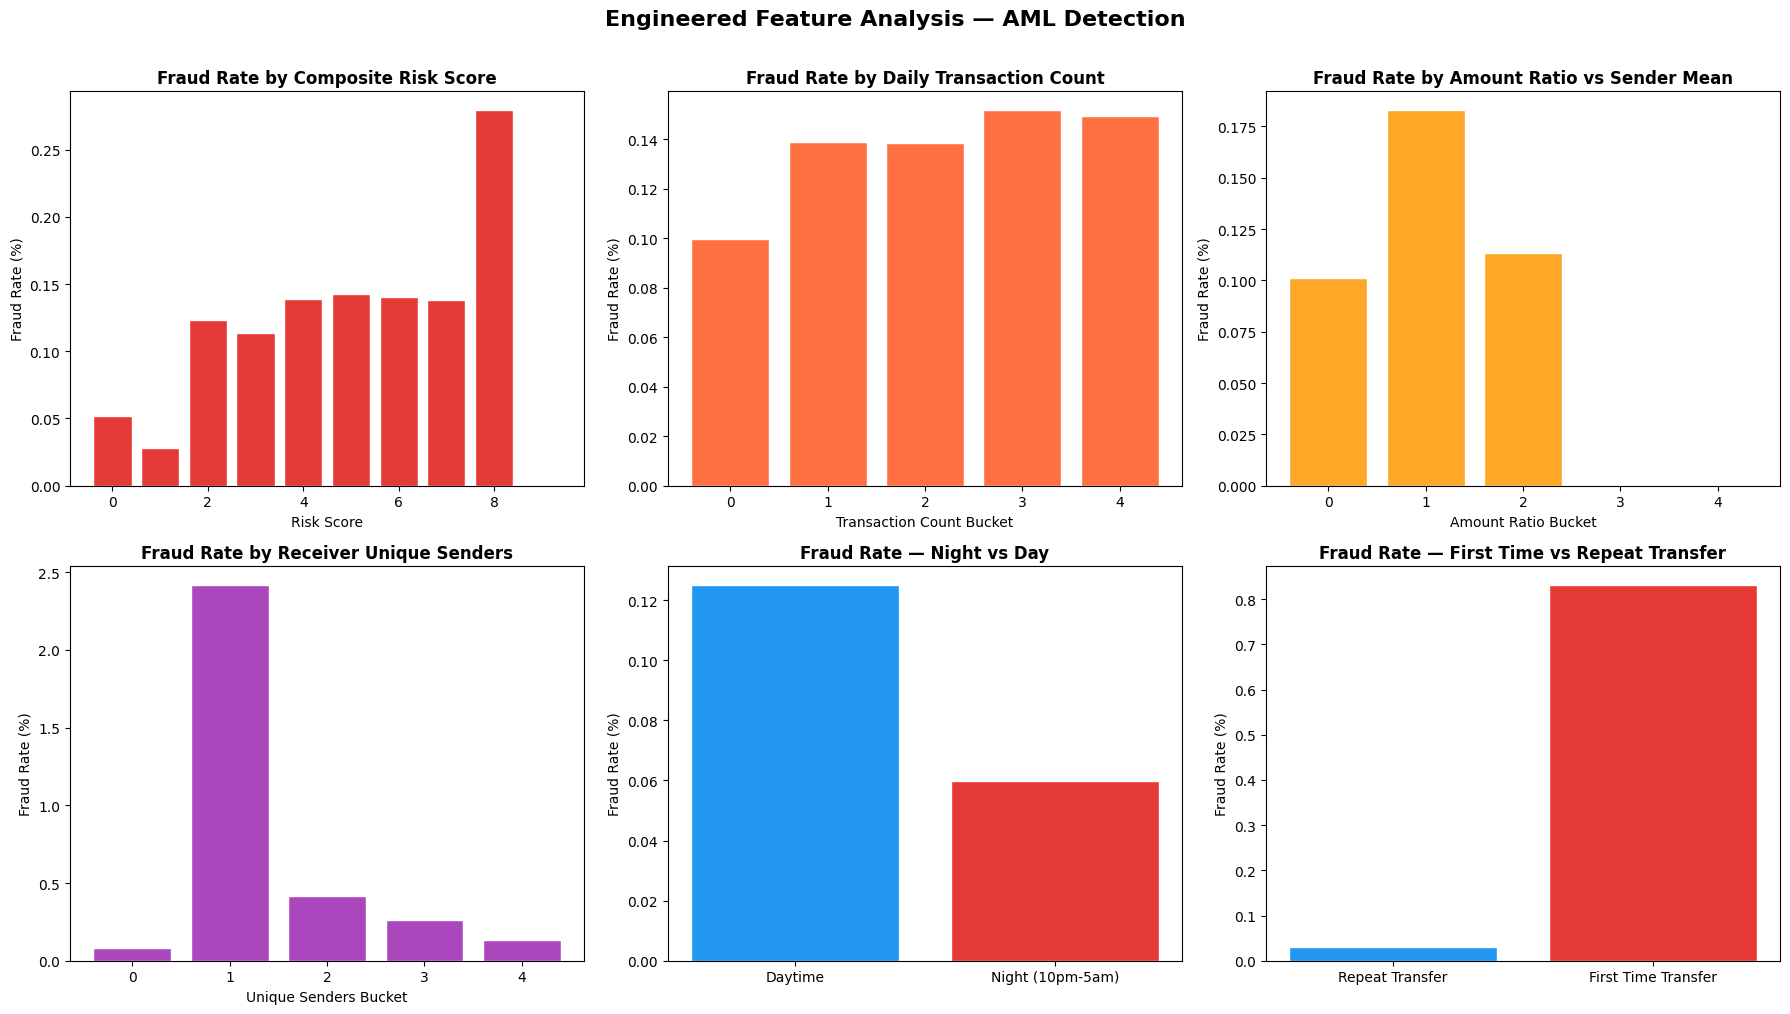

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# ── Chart 1: Composite risk score vs fraud ───────────────
fraud_by_risk = df.groupby(
    'composite_risk_score'
)['Is Laundering'].mean() * 100

axes[0].bar(
    fraud_by_risk.index,
    fraud_by_risk.values,
    color='#E53935',
    edgecolor='white'
)
axes[0].set_title('Fraud Rate by Composite Risk Score', fontweight='bold')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Fraud Rate (%)')

# ── Chart 2: Velocity vs fraud ───────────────────────────
vel_fraud = df.groupby(
    pd.cut(df['sender_txn_count_per_day'], bins=5)
)['Is Laundering'].mean() * 100

axes[1].bar(
    range(len(vel_fraud)),
    vel_fraud.values,
    color='#FF7043',
    edgecolor='white'
)
axes[1].set_title('Fraud Rate by Daily Transaction Count', fontweight='bold')
axes[1].set_xlabel('Transaction Count Bucket')
axes[1].set_ylabel('Fraud Rate (%)')

# ── Chart 3: Amount ratio vs fraud ───────────────────────
ratio_fraud = df.groupby(
    pd.cut(
        df['amount_ratio_vs_sender_mean'].clip(0, 10),
        bins=5
    )
)['Is Laundering'].mean() * 100

axes[2].bar(
    range(len(ratio_fraud)),
    ratio_fraud.values,
    color='#FFA726',
    edgecolor='white'
)
axes[2].set_title('Fraud Rate by Amount Ratio vs Sender Mean', fontweight='bold')
axes[2].set_xlabel('Amount Ratio Bucket')
axes[2].set_ylabel('Fraud Rate (%)')

# ── Chart 4: Receiver unique senders vs fraud ────────────
recv_fraud = df.groupby(
    pd.cut(
        df['receiver_unique_senders'].clip(0, 50),
        bins=5
    )
)['Is Laundering'].mean() * 100

axes[3].bar(
    range(len(recv_fraud)),
    recv_fraud.values,
    color='#AB47BC',
    edgecolor='white'
)
axes[3].set_title('Fraud Rate by Receiver Unique Senders', fontweight='bold')
axes[3].set_xlabel('Unique Senders Bucket')
axes[3].set_ylabel('Fraud Rate (%)')

# ── Chart 5: Night transaction vs fraud ──────────────────
night_fraud = df.groupby(
    'is_night_transaction'
)['Is Laundering'].mean() * 100

axes[4].bar(
    ['Daytime', 'Night (10pm-5am)'],
    night_fraud.values,
    color=['#2196F3', '#E53935'],
    edgecolor='white'
)
axes[4].set_title('Fraud Rate — Night vs Day', fontweight='bold')
axes[4].set_ylabel('Fraud Rate (%)')

# ── Chart 6: First time transfer vs fraud ────────────────
first_fraud = df.groupby(
    'is_first_time_transfer'
)['Is Laundering'].mean() * 100

axes[5].bar(
    ['Repeat Transfer', 'First Time Transfer'],
    first_fraud.values,
    color=['#2196F3', '#E53935'],
    edgecolor='white'
)
axes[5].set_title('Fraud Rate — First Time vs Repeat Transfer', fontweight='bold')
axes[5].set_ylabel('Fraud Rate (%)')

plt.suptitle(
    'Engineered Feature Analysis — AML Detection',
    fontsize=16, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

## Build final feature engineered dataset

## unique sender and unique receiver count

In [12]:
# ============================================================
# UNIQUE SENDER AND RECEIVER COUNTS
# ============================================================
# unique_senders_to_receiver:
# How many DIFFERENT accounts send money TO this receiver?
# Normal person : 2-5 (salary, family)
# Money mule    : 100-1000+ (collecting dirty money)
#
# unique_receivers_from_sender:
# How many DIFFERENT accounts does this sender pay?
# Normal person : 5-20 (bills, shopping)
# Launderer     : 50-500+ (distributing dirty money)
# ============================================================

# ── Unique senders to each receiver ─────────────────────────
df['unique_senders_to_receiver'] = df.groupby(
    'Receiver_Account_Encoded'
)['Sender_Account_Encoded'].transform('nunique')

# ── Unique receivers from each sender ───────────────────────
df['unique_receivers_from_sender'] = df.groupby(
    'Sender_Account_Encoded'
)['Receiver_Account_Encoded'].transform('nunique')

# ── Unique banks this sender has ever used ───────────────────
df['sender_unique_banks_total'] = df.groupby(
    'Sender_Account_Encoded'
)['Sender Bank ID'].transform('nunique')

# ── Unique banks this receiver receives from ─────────────────
df['receiver_unique_banks_total'] = df.groupby(
    'Receiver_Account_Encoded'
)['Receiver Bank ID'].transform('nunique')

print("Unique sender/receiver features created!")
print("\nFraud vs Normal comparison:")
unique_cols = [
    'unique_senders_to_receiver',
    'unique_receivers_from_sender',
    'sender_unique_banks_total',
    'receiver_unique_banks_total'
]
print(df.groupby('Is Laundering')[unique_cols].mean().round(2))

Unique sender/receiver features created!

Fraud vs Normal comparison:
               unique_senders_to_receiver  unique_receivers_from_sender  \
Is Laundering                                                             
0                                    3.83                        700.47   
1                                    6.54                        998.97   

               sender_unique_banks_total  receiver_unique_banks_total  
Is Laundering                                                          
0                                    1.0                          1.0  
1                                    1.0                          1.0  


## Creating log amounts

In [13]:
import numpy as np

df['Amount_Paid_Log'] = np.log1p(df['Amount Paid'])
df['Amount_Received_Log'] = np.log1p(df['Amount Received'])

## Create fan-in account 

In [14]:
fan_in = (
    df.groupby('Receiver_Account_Encoded')['Sender_Account_Encoded']
      .transform('nunique')
)

df['fan_in_count'] = fan_in

## Create fan-out account

In [15]:
fan_out = (
    df.groupby('Sender_Account_Encoded')['Receiver_Account_Encoded']
      .transform('nunique')
)

df['fan_out_count'] = fan_out

## Create sender transaction per day

In [16]:
sender_daily = (
    df.groupby(['Sender_Account_Encoded', 'Day'])['Day']
      .transform('count')
)

df['sender_txn_count_per_day'] = sender_daily

## Fan-in and Fan-out score

In [17]:
# ============================================================
# FAN-IN AND FAN-OUT SCORES
# ============================================================
# Fan-in  = many accounts sending TO one account
#           Pattern: dirty money being COLLECTED at one point
#
# Fan-out = one account sending TO many accounts
#           Pattern: dirty money being SPREAD/LAYERED
#
# Fan ratio = fan_in / fan_out
# High ratio = account collects more than distributes = MULE
# Low ratio  = account distributes more than collects = LAUNDERER
# ============================================================

# ── Total transactions received by each receiver ─────────────
receiver_total_txn = df.groupby(
    'Receiver_Account_Encoded'
)['Amount_Paid_Log'].transform('count')

# ── Total transactions sent by each sender ───────────────────
sender_total_txn = df.groupby(
    'Sender_Account_Encoded'
)['Amount_Paid_Log'].transform('count')

# ── Fan-in score ─────────────────────────────────────────────
# Ratio of unique senders to total transactions received
# Higher = more concentrated incoming money = suspicious
df['fan_in_score'] = (
    df['unique_senders_to_receiver'] /
    (receiver_total_txn + 1)
)

# ── Fan-out score ─────────────────────────────────────────────
# Ratio of unique receivers to total transactions sent
# Higher = spreading money to many places = suspicious
df['fan_out_score'] = (
    df['unique_receivers_from_sender'] /
    (sender_total_txn + 1)
)

# ── Raw fan counts ────────────────────────────────────────────
df['fan_in_count']  = df['unique_senders_to_receiver']
df['fan_out_count'] = df['unique_receivers_from_sender']

# ── Fan ratio ─────────────────────────────────────────────────
# fan_in / fan_out tells us the account TYPE
df['fan_ratio'] = (
    df['fan_in_count'] /
    (df['fan_out_count'] + 0.001)
)

print("Fan-in and fan-out features created!")
print("\nFraud vs Normal comparison:")
fan_cols = [
    'fan_in_score',
    'fan_out_score',
    'fan_in_count',
    'fan_out_count',
    'fan_ratio'
]
print(df.groupby('Is Laundering')[fan_cols].mean().round(4))

Fan-in and fan-out features created!

Fraud vs Normal comparison:
               fan_in_score  fan_out_score  fan_in_count  fan_out_count  \
Is Laundering                                                             
0                    0.1720         0.1617        3.8321       700.4687   
1                    0.3943         0.3698        6.5443       998.9672   

               fan_ratio  
Is Laundering             
0                 1.3494  
1                 2.1560  


## Potential mule account detection

In [18]:
# ============================================================
# MULE ACCOUNT DETECTION
# ============================================================
# A money mule RECEIVES dirty money from criminals
# then QUICKLY passes it to other accounts
# keeping a small cut for themselves
#
# Signs of a mule:
# 1. Receives from MANY different senders (high fan-in)
# 2. Sends to MANY different receivers (high fan-out)
# 3. Amount received ≈ Amount sent (just passing through)
# 4. High transaction velocity
# ============================================================

# ── Amount balance ratio ──────────────────────────────────────
# Compare total amount received vs total amount sent
# Mule accounts: ratio close to 1.0
# (money in = money out, just passing through)

total_received = df.groupby(
    'Receiver_Account_Encoded'
)['Amount_Received_Log'].transform('sum')

total_sent = df.groupby(
    'Sender_Account_Encoded'
)['Amount_Paid_Log'].transform('sum')

df['account_amount_balance_ratio'] = (
    total_received / (total_sent + 0.001)
)

# ── Mule score — combine 4 signals ───────────────────────────
# Each condition that matches adds 1 point
# Score 0 = not a mule
# Score 4 = very likely a mule

# Threshold: top 10% of fan-in counts = high fan-in
high_fan_in_threshold  = df['fan_in_count'].quantile(0.90)
high_fan_out_threshold = df['fan_out_count'].quantile(0.90)

high_fan_in  = (df['fan_in_count']  > high_fan_in_threshold)
high_fan_out = (df['fan_out_count'] > high_fan_out_threshold)

# Balance ratio between 0.8 and 1.2 = passing money through
balance_near_one = (
    (df['account_amount_balance_ratio'] > 0.8) &
    (df['account_amount_balance_ratio'] < 1.2)
)

# High velocity = more than 10 transactions per day
high_velocity = (df['sender_txn_count_per_day'] > 10)

df['mule_score'] = (
    high_fan_in.astype(int)      +
    high_fan_out.astype(int)     +
    balance_near_one.astype(int) +
    high_velocity.astype(int)
)

# ── Is potential mule flag ────────────────────────────────────
# Flag as mule if score is 3 or above out of 4
df['is_potential_mule'] = (
    df['mule_score'] >= 3
).astype(int)

print("Mule detection features created!")
print(f"\nPotential mules detected : {df['is_potential_mule'].sum():,}")

print("\nMule score distribution:")
print(df['mule_score'].value_counts().sort_index())

print("\nFraud rate by mule score:")
mule_fraud = df.groupby('mule_score')['Is Laundering'].mean() * 100
for score, rate in mule_fraud.items():
    bar = '█' * int(rate * 5)
    print(f"  Score {score}: {rate:.4f}%  {bar}")

print(f"\nFraud rate in mule accounts  : {df[df['is_potential_mule']==1]['Is Laundering'].mean()*100:.4f}%")
print(f"Fraud rate in normal accounts: {df[df['is_potential_mule']==0]['Is Laundering'].mean()*100:.4f}%")

Mule detection features created!

Potential mules detected : 19,426

Mule score distribution:
mule_score
0    2726260
1    1794458
2     538192
3      19424
4          2
Name: count, dtype: int64

Fraud rate by mule score:
  Score 0: 0.0815%  
  Score 1: 0.1148%  
  Score 2: 0.1570%  
  Score 3: 0.2471%  █
  Score 4: 50.0000%  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

Fraud rate in mule accounts  : 0.2522%
Fraud rate in normal accounts: 0.1014%


## Money sent to potential mule account

In [19]:
print(df.columns.tolist())

['Hour', 'Day', 'DayOfWeek', 'IsWeekend', 'Sender Bank ID', 'Receiver Bank ID', 'is_cross_bank', 'Sender_Account_Encoded', 'Receiver_Account_Encoded', 'is_self_transfer', 'Amount Paid', 'Amount Received', 'amount_vs_account_median', 'is_currency_mismatch', 'is_amount_outlier_iqr', 'is_amount_outlier_zscore', 'is_account_level_outlier', 'is_high_velocity', 'outlier_score', 'is_outlier', 'txn_count_per_sender_hour', 'txn_count_per_sender_day', 'fmt_ACH', 'fmt_Bitcoin', 'fmt_Cash', 'fmt_Cheque', 'fmt_Credit Card', 'fmt_Reinvestment', 'fmt_Wire', 'Payment_Currency_Encoded', 'Receiving_Currency_Encoded', 'Is Laundering', 'Amount_Paid_Log', 'sender_txn_count_per_day', 'sender_txn_count_per_hour', 'sender_total_amount_per_day', 'sender_unique_receivers_per_day', 'amount_ratio_vs_sender_mean', 'amount_ratio_vs_sender_median', 'sender_amount_zscore', 'is_sender_max_transaction', 'Amount_Paid_Raw', 'is_round_amount', 'is_just_below_threshold', 'avg_txn_size_today', 'is_structuring_pattern', 'sen

In [20]:
# ============================================================
# MONEY SENT TO MULE ACCOUNTS
# ============================================================
# If Account A sends money TO a mule account
# Account A is ALSO suspicious
# This is called suspicion propagation
#
# Example:
# Criminal → Mule Account → Clean Account
# We flag not just the mule but also
# whoever is FEEDING the mule
# ============================================================

# ── Get mule score for each RECEIVER ─────────────────────────
# Map each receiver account's mule score
# onto the transaction row

receiver_mule_lookup = df.groupby(
    'Receiver_Account_Encoded'
)['mule_score'].first()

df['receiver_mule_score'] = df[
    'Receiver_Account_Encoded'
].map(receiver_mule_lookup).fillna(0)

# ── Is this transaction sending TO a mule ────────────────────
df['is_sending_to_mule'] = (
    df['receiver_mule_score'] >= 3
).astype(int)

# ── Amount sent to mule in this transaction ───────────────────
df['amount_sent_to_mule'] = (
    df['Amount_Paid_Log'] * df['is_sending_to_mule']
)

# ── Total amount this sender has ever sent to mules ───────────
df['sender_total_sent_to_mules'] = df.groupby(
    'Sender_Account_Encoded'
)['amount_sent_to_mule'].transform('sum')

# ── Percentage of this sender's transactions going to mules ───
df['pct_transactions_to_mules'] = df.groupby(
    'Sender_Account_Encoded'
)['is_sending_to_mule'].transform('mean')

print("Money sent to mule features created!")
print(f"\nTransactions sending to mules: {df['is_sending_to_mule'].sum():,}")

print("\nFraud rate — sending to mule vs not:")
mule_send_rate = df.groupby(
    'is_sending_to_mule'
)['Is Laundering'].mean() * 100
print(mule_send_rate.round(4))

print("\nFraud vs Normal comparison:")
mule_send_cols = [
    'is_sending_to_mule',
    'receiver_mule_score',
    'pct_transactions_to_mules',
    'sender_total_sent_to_mules'
]
print(df.groupby('Is Laundering')[mule_send_cols].mean().round(4))

Money sent to mule features created!

Transactions sending to mules: 5,662

Fraud rate — sending to mule vs not:
is_sending_to_mule
0    0.1011
1    0.8654
Name: Is Laundering, dtype: float64

Fraud vs Normal comparison:
               is_sending_to_mule  receiver_mule_score  \
Is Laundering                                            
0                          0.0011               0.3776   
1                          0.0095               0.6266   

               pct_transactions_to_mules  sender_total_sent_to_mules  
Is Laundering                                                         
0                                 0.0011                    189.1467  
1                                 0.0059                    271.5199  


## Total transaction count features

In [21]:
# ============================================================
# TOTAL TRANSACTION COUNT FEATURES
# ============================================================
# Captures LIFETIME behaviour of each account
# across the entire dataset
#
# High total count = either legitimate business
# OR active money laundering operation
# Combined with other features this is very powerful
# ============================================================

# ── Total transactions ever sent by this sender ───────────────
df['sender_total_txn_count'] = df.groupby(
    'Sender_Account_Encoded'
)['Amount_Paid_Log'].transform('count')

# ── Total transactions ever received by this receiver ─────────
df['receiver_total_txn_count'] = df.groupby(
    'Receiver_Account_Encoded'
)['Amount_Received_Log'].transform('count')

# ── Total amount ever sent by this sender ─────────────────────
df['sender_total_amount_sent'] = df.groupby(
    'Sender_Account_Encoded'
)['Amount_Paid_Log'].transform('sum')

# ── Total amount ever received by this receiver ───────────────
df['receiver_total_amount_received'] = df.groupby(
    'Receiver_Account_Encoded'
)['Amount_Received_Log'].transform('sum')

# ── Average transaction amount for this sender ────────────────
df['sender_avg_txn_amount'] = (
    df['sender_total_amount_sent'] /
    (df['sender_total_txn_count'] + 1)
)

# ── Average transaction amount for this receiver ──────────────
df['receiver_avg_txn_amount'] = (
    df['receiver_total_amount_received'] /
    (df['receiver_total_txn_count'] + 1)
)

# ── Transaction count ratio sender vs receiver ────────────────
# Helps identify heavily one-directional accounts
df['txn_count_ratio'] = (
    df['sender_total_txn_count'] /
    (df['receiver_total_txn_count'] + 1)
)

print("Total transaction count features created!")
print("\nFraud vs Normal comparison:")
count_cols = [
    'sender_total_txn_count',
    'receiver_total_txn_count',
    'sender_total_amount_sent',
    'receiver_total_amount_received',
    'sender_avg_txn_amount',
    'receiver_avg_txn_amount',
    'txn_count_ratio'
]
print(df.groupby('Is Laundering')[count_cols].mean().round(2))

Total transaction count features created!

Fraud vs Normal comparison:
               sender_total_txn_count  receiver_total_txn_count  \
Is Laundering                                                     
0                             8253.29                     26.94   
1                            11741.02                     21.03   

               sender_total_amount_sent  receiver_total_amount_received  \
Is Laundering                                                             
0                              59649.23                          199.89   
1                              84675.77                          166.02   

               sender_avg_txn_amount  receiver_avg_txn_amount  txn_count_ratio  
Is Laundering                                                                   
0                               6.92                     6.95           347.01  
1                               7.45                     7.14           484.79  


## Update composite risk score

In [22]:
# ============================================================
# UPDATE COMPOSITE RISK SCORE
# ============================================================
# Add the new mule and network signals
# to the existing composite risk score
# ============================================================

df['composite_risk_score'] = (
    # ── Original signals ────────────────────────────────
    df['is_amount_outlier_iqr'].fillna(0)              +
    df['is_amount_outlier_zscore'].fillna(0)           +
    df['is_account_level_outlier'].fillna(0)           +
    df['is_high_velocity'].fillna(0)                   +
    (df['sender_txn_count_per_day'] > 10).astype(int)  +
    df['is_round_amount'].fillna(0)                    +
    df['is_structuring_pattern'].fillna(0)             +
    df['is_self_transfer'].fillna(0)                   +
    df['is_first_time_transfer'].fillna(0)             +
    df['is_cross_bank'].fillna(0)                      +
    df['is_night_transaction'].fillna(0)               +
    df['is_currency_mismatch'].fillna(0)               +

    # ── New signals ─────────────────────────────────────
    df['is_potential_mule'].fillna(0)                  +
    df['is_sending_to_mule'].fillna(0)                 +
    (df['fan_in_count']  > 50).astype(int)             +
    (df['fan_out_count'] > 50).astype(int)             +
    (df['unique_senders_to_receiver'] > 20).astype(int)
)

print("Composite risk score updated!")
print(f"Max possible score now: 17")
print("\nNew score distribution:")
print(df['composite_risk_score'].value_counts().sort_index())

print("\nFraud rate by updated composite score:")
updated_fraud = df.groupby(
    'composite_risk_score'
)['Is Laundering'].mean() * 100

for score, rate in updated_fraud.items():
    bar = '█' * int(rate * 3)
    print(f"  Score {score:2}: {rate:.4f}%  {bar}")

Composite risk score updated!
Max possible score now: 17

New score distribution:
composite_risk_score
0       17447
1     1217670
2     1538359
3     1119658
4      532930
5      386981
6      202093
7       53827
8        8703
9         629
10         39
Name: count, dtype: int64

Fraud rate by updated composite score:
  Score  0: 0.0516%  
  Score  1: 0.0278%  
  Score  2: 0.1209%  
  Score  3: 0.1146%  
  Score  4: 0.1372%  
  Score  5: 0.1504%  
  Score  6: 0.1386%  
  Score  7: 0.1486%  
  Score  8: 0.1379%  
  Score  9: 0.3180%  
  Score 10: 0.0000%  


## Rebuild and save complete dataset

In [23]:
import joblib
import os

# ── All new features added in this session ───────────────────
new_advanced_features = [
    # Unique counts
    'unique_senders_to_receiver',
    'unique_receivers_from_sender',
    'sender_unique_banks_total',
    'receiver_unique_banks_total',

    # Fan in and out
    'fan_in_score',
    'fan_out_score',
    'fan_in_count',
    'fan_out_count',
    'fan_ratio',

    # Mule detection
    'mule_score',
    'is_potential_mule',
    'account_amount_balance_ratio',

    # Sending to mule
    'is_sending_to_mule',
    'receiver_mule_score',
    'amount_sent_to_mule',
    'sender_total_sent_to_mules',
    'pct_transactions_to_mules',

    # Total counts
    'sender_total_txn_count',
    'receiver_total_txn_count',
    'sender_total_amount_sent',
    'receiver_total_amount_received',
    'sender_avg_txn_amount',
    'receiver_avg_txn_amount',
    'txn_count_ratio',
]

# ── Your existing 55 features ────────────────────────────────
existing_features = [
    'Hour', 'Day', 'DayOfWeek', 'IsWeekend',
    'Sender Bank ID', 'Receiver Bank ID',
    'Sender_Account_Encoded', 'Receiver_Account_Encoded',
    'Amount_Paid_Log',
    'is_cross_bank', 'is_self_transfer',
    'is_currency_mismatch', 'is_outlier',
    'outlier_score',
    'is_amount_outlier_iqr',
    'is_amount_outlier_zscore',
    'is_account_level_outlier',
    'is_high_velocity',
    'txn_count_per_sender_hour',
    'txn_count_per_sender_day',
    'amount_vs_account_median',
    'Payment_Currency_Encoded',
    'Receiving_Currency_Encoded',
    'sender_txn_count_per_day',
    'sender_txn_count_per_hour',
    'sender_total_amount_per_day',
    'sender_unique_receivers_per_day',
    'amount_ratio_vs_sender_mean',
    'amount_ratio_vs_sender_median',
    'sender_amount_zscore',
    'is_sender_max_transaction',
    'is_round_amount',
    'is_just_below_threshold',
    'is_structuring_pattern',
    'avg_txn_size_today',
    'sender_unique_banks',
    'receiver_unique_senders',
    'bank_pair_fraud_rate',
    'is_first_time_transfer',
    'receiver_concentration',
    'is_night_transaction',
    'is_early_morning',
    'hour_deviation_from_usual',
    'is_weekend_large_amount',
    'is_night_large_amount',
    'is_same_currency',
    'is_high_risk_format',
    'composite_risk_score',
]

# ── OHE format columns ───────────────────────────────────────
fmt_cols = [c for c in df.columns if c.startswith('fmt_')]

# ── Combine all features ─────────────────────────────────────
all_features = existing_features + new_advanced_features + fmt_cols

# Keep only columns that exist in df
all_features = [f for f in all_features if f in df.columns]

# Remove duplicates while preserving order
seen = set()
all_features = [
    f for f in all_features
    if not (f in seen or seen.add(f))
]

# ── Build final dataset ──────────────────────────────────────
df_featured = df[all_features + ['Is Laundering']].copy()
df_featured = df_featured.dropna()

print("=" * 50)
print("FINAL FEATURE ENGINEERED DATASET")
print("=" * 50)
print(f"Shape          : {df_featured.shape}")
print(f"Total features : {len(all_features)}")
print(f"Fraud rows     : {df_featured['Is Laundering'].sum():,}")
print(f"Normal rows    : {(df_featured['Is Laundering']==0).sum():,}")
print(f"Missing values : {df_featured.isnull().sum().sum()}")

print(f"\nAll {len(all_features)} features:")
for i, col in enumerate(all_features, 1):
    print(f"  {i:2}. {col}")

# ── Save ─────────────────────────────────────────────────────
os.makedirs('featured', exist_ok=True)

df_featured.to_csv(
    'featured/featured_transactions.csv', index=False
)
joblib.dump(
    all_features,
    'featured/feature_names.pkl'
)

print("\nFiles saved!")
print("  featured/featured_transactions.csv")
print("  featured/feature_names.pkl")
print(f"\nFeature Engineering Complete!")
print(f"Previous: 55 features")
print(f"New total: {len(all_features)} features")
print(f"\nNext → Notebook 5: XGBoost Model")

FINAL FEATURE ENGINEERED DATASET
Shape          : (5078336, 80)
Total features : 79
Fraud rows     : 5,177
Normal rows    : 5,073,159
Missing values : 0

All 79 features:
   1. Hour
   2. Day
   3. DayOfWeek
   4. IsWeekend
   5. Sender Bank ID
   6. Receiver Bank ID
   7. Sender_Account_Encoded
   8. Receiver_Account_Encoded
   9. Amount_Paid_Log
  10. is_cross_bank
  11. is_self_transfer
  12. is_currency_mismatch
  13. is_outlier
  14. outlier_score
  15. is_amount_outlier_iqr
  16. is_amount_outlier_zscore
  17. is_account_level_outlier
  18. is_high_velocity
  19. txn_count_per_sender_hour
  20. txn_count_per_sender_day
  21. amount_vs_account_median
  22. Payment_Currency_Encoded
  23. Receiving_Currency_Encoded
  24. sender_txn_count_per_day
  25. sender_txn_count_per_hour
  26. sender_total_amount_per_day
  27. sender_unique_receivers_per_day
  28. amount_ratio_vs_sender_mean
  29. amount_ratio_vs_sender_median
  30. sender_amount_zscore
  31. is_sender_max_transaction
  32. is